In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift

## Kernel density estimation (KDE)

In [2]:
def gaussian_kernel_1d(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

# KDE 1D con kernel gaussiano
def kde_1d(x_grid, samples, h):
    u = (x_grid[:, None] - samples[None, :]) / h
    density = np.mean(gaussian_kernel_1d(u), axis=1) / h
    return density

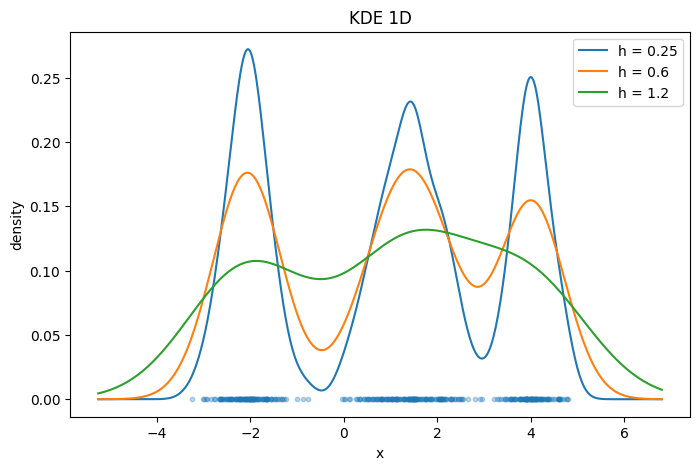

In [3]:
rng = np.random.default_rng(7)

x1 = rng.normal(loc=-2.0, scale=0.5, size=120)
x2 = rng.normal(loc=1.5, scale=0.7, size=150)
x3 = rng.normal(loc=4.0, scale=0.4, size=100)

x_samples = np.concatenate([x1, x2, x3])

x_grid = np.linspace(x_samples.min() - 2, x_samples.max() + 2, 500)

h_values = [0.25, 0.6, 1.2]

plt.figure(figsize=(8, 5))
for h in h_values:
    density = kde_1d(x_grid, x_samples, h)
    plt.plot(x_grid, density, label=f"h = {h}")

plt.scatter(x_samples, np.zeros_like(x_samples), s=10, alpha=0.3)
plt.title("KDE 1D")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

In [4]:
def gaussian_kernel_2d(U):
    norm_sq = np.sum(U**2, axis=-1)
    return np.exp(-0.5 * norm_sq) / (2 * np.pi)

# KDE 2D con kernel gaussiano isotrópico
def kde_2d(grid_points, X, h):
    U = (grid_points[:, None, :] - X[None, :, :]) / h
    density = np.mean(gaussian_kernel_2d(U), axis=1) / (h**2)
    return density

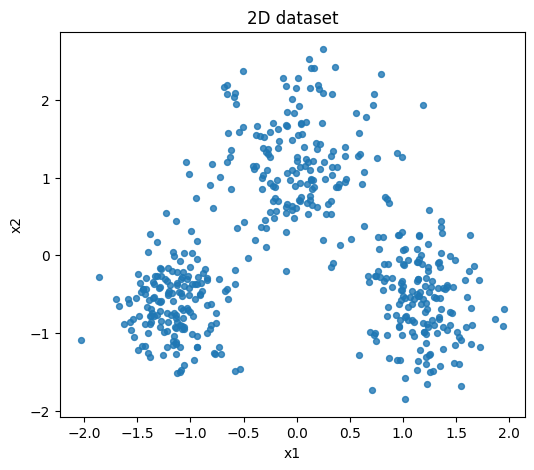

In [5]:
X2, y_true = make_blobs(
    n_samples=500,
    centers=[[-3, -1], [0, 2], [3, -1]],
    cluster_std=[0.7, 1.0, 0.8],
    random_state=42
)

X2 = StandardScaler().fit_transform(X2)

plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], s=18, alpha=0.8)
plt.title("2D dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [6]:
def plot_kde_2d(X, h, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    density = kde_2d(grid, X, h).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, density, levels=30, alpha=0.75)
    plt.scatter(X[:, 0], X[:, 1], s=12, c="black", alpha=0.5)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

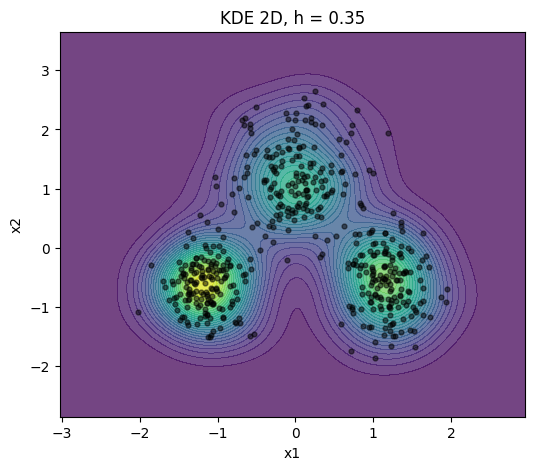

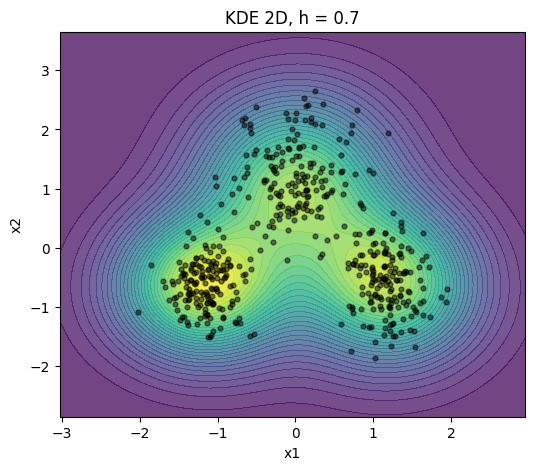

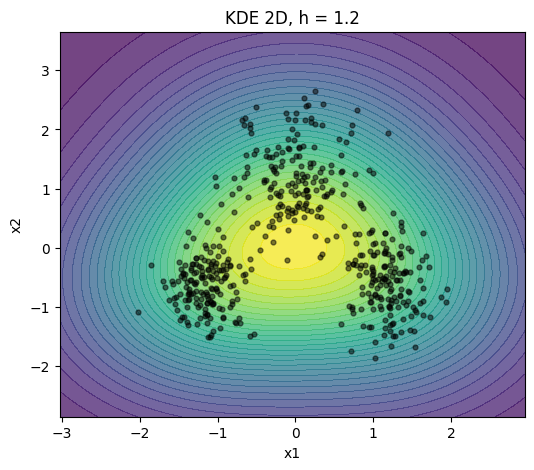

In [7]:
plot_kde_2d(X2, h=0.35, title="KDE 2D, h = 0.35")
plot_kde_2d(X2, h=0.7, title="KDE 2D, h = 0.7")
plot_kde_2d(X2, h=1.2, title="KDE 2D, h = 1.2")

## Mean Shift

In [8]:
def mean_shift_vector(x, X, h):
    U = (x[None, :] - X) / h
    weights = gaussian_kernel_2d(U)
    weighted_mean = np.sum(weights[:, None] * X, axis=0) / np.sum(weights)
    shift = weighted_mean - x
    return shift, weighted_mean

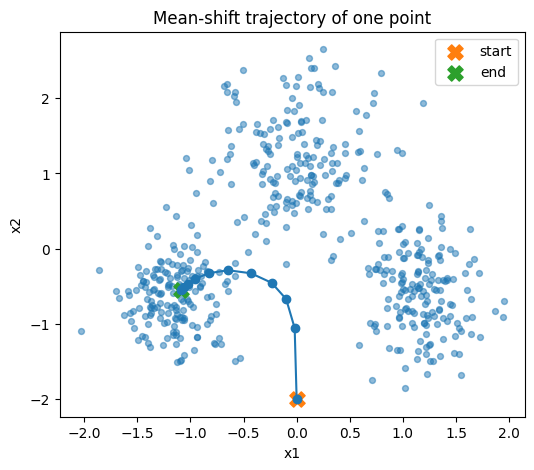

In [18]:
x0 = np.array([0.0, -2.0])
h = 0.7

trajectory = [x0.copy()]
x = x0.copy()

for _ in range(12):
    shift, x_new = mean_shift_vector(x, X2, h)
    trajectory.append(x_new.copy())
    x = x_new

trajectory = np.array(trajectory)

plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], s=18, alpha=0.5)
plt.plot(trajectory[:, 0], trajectory[:, 1], marker="o")
plt.scatter(trajectory[0, 0], trajectory[0, 1], s=120, marker="X", label="start")
plt.scatter(trajectory[-1, 0], trajectory[-1, 1], s=120, marker="X", label="end")
plt.title("Mean-shift trajectory of one point")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [10]:
# Ejecuta mean shift en todos los puntos
def mean_shift(X, h, max_iter=100, tol=1e-3):
    shifted_points = X.copy()

    for i in range(X.shape[0]):
        x = shifted_points[i].copy()

        for _ in range(max_iter):
            shift, x_new = mean_shift_vector(x, X, h)
            if np.linalg.norm(shift) < tol:
                break
            x = x_new

        shifted_points[i] = x

    return shifted_points

In [11]:
# Luego, agrupa puntos convergidos cercanos en modos representativos
def cluster_modes(shifted_points, merge_tol=0.2):
    modes = []
    labels = np.full(shifted_points.shape[0], -1, dtype=int)

    for i, p in enumerate(shifted_points):
        assigned = False
        for j, m in enumerate(modes):
            if np.linalg.norm(p - m) < merge_tol:
                labels[i] = j
                assigned = True
                break
        if not assigned:
            modes.append(p.copy())
            labels[i] = len(modes) - 1

    modes = np.array(modes)
    return modes, labels

In [12]:
h = 0.7

shifted = mean_shift(X2, h=h, max_iter=100, tol=1e-3)
modes, labels_ms = cluster_modes(shifted, merge_tol=0.18)

print("Mean Shift from scratch")
print("  Number of clusters:", len(modes))

Mean Shift from scratch
  Number of clusters: 3


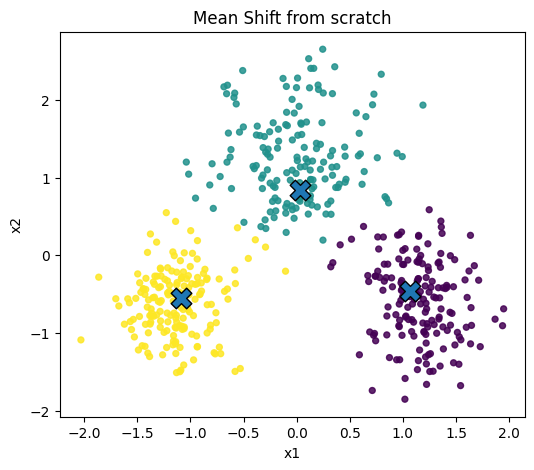

In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_ms, s=18, alpha=0.85)
plt.scatter(modes[:, 0], modes[:, 1], s=220, marker="X", edgecolor="black")
plt.title("Mean Shift from scratch")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## Skelearn

In [14]:
ms_sklearn = MeanShift(bandwidth=0.7, bin_seeding=False)
labels_sk = ms_sklearn.fit_predict(X2)
centers_sk = ms_sklearn.cluster_centers_

print("sklearn MeanShift")
print("  Number of clusters:", len(centers_sk))

sklearn MeanShift
  Number of clusters: 3


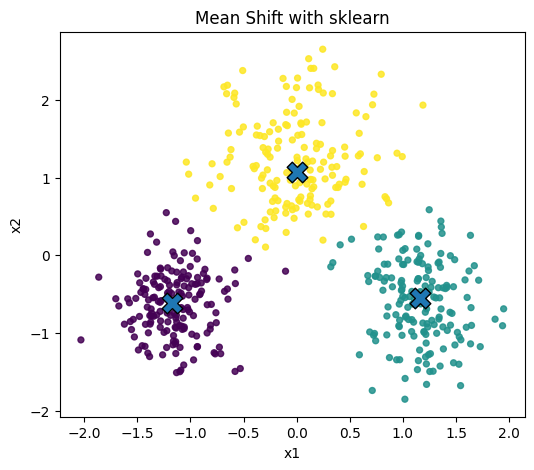

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_sk, s=18, alpha=0.85)
plt.scatter(centers_sk[:, 0], centers_sk[:, 1], s=220, marker="X", edgecolor="black")
plt.title("Mean Shift with sklearn")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

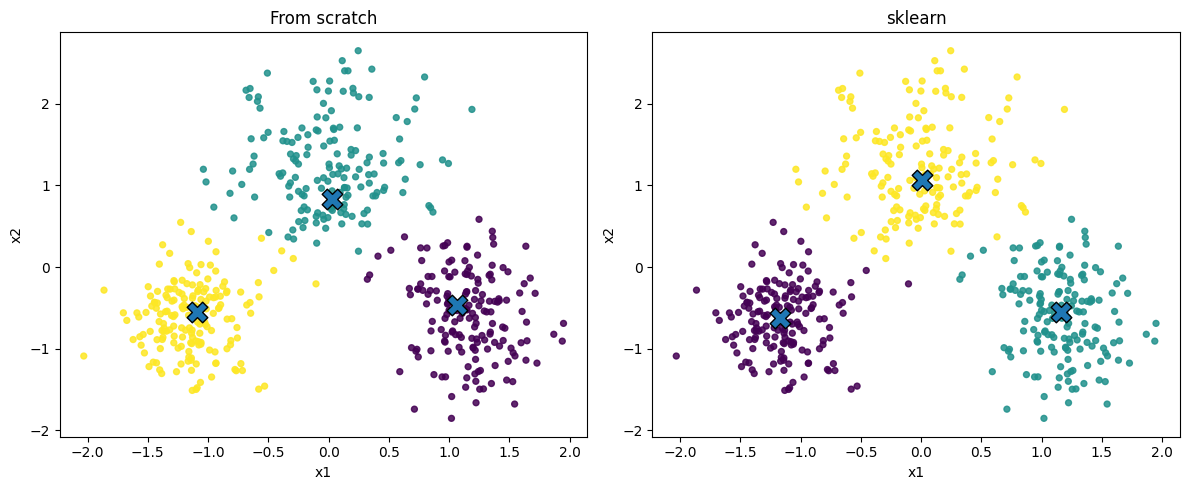

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X2[:, 0], X2[:, 1], c=labels_ms, s=18, alpha=0.85)
axes[0].scatter(modes[:, 0], modes[:, 1], s=220, marker="X", edgecolor="black")
axes[0].set_title("From scratch")

axes[1].scatter(X2[:, 0], X2[:, 1], c=labels_sk, s=18, alpha=0.85)
axes[1].scatter(centers_sk[:, 0], centers_sk[:, 1], s=220, marker="X", edgecolor="black")
axes[1].set_title("sklearn")

for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()